# About project
The code needed to execute and analyse the tasks given is written in src, while this ipynb file works as the report; analyzing the results and text part of the task. You can find all backend functions in src/tma_4215_project_1/interpolation.py and functions.py, while computations and plots for analysis lies within the analysis folders. 
```text
project_1/
├── notebooks/
│   └── project_1.ipynb
│
├── src/
│   └── tma4215_project1/
│       ├── functions.py
│       │
│       ├── interpolation/
│       │   ├── methods.py
│       │   ├── nodes.py
│       │   └── norms.py
│       │
│       └── analysis/
│           ├── computations/
│           │   ├── lagrange_computations.py
│           │   ├── piecewise_computations.py
│           │   ├── rbf_computations.py
│           │   └── runtime_computations.py
│           │
│           └── plots/
│               ├── lagrange_plots.py
│               ├── piecewise_plots.py
│               └── rbf_plots.py
│
├── outputs/
├── docs/
├── pyproject.toml
├── uv.lock
└── README.md
```


### AI declaration
AI has been used mainly for
- Formatting
- Debugging
- Discussion

In case of mistakes in code a common prompt would be to explain the task I'm trying to solve, then paste my code and let it look for syntatic or logical errors. When I encountered errors I would attempt to fix these myself, without using AI to do this for me. 

In case of text boxes, nice tables etc., I have often copied layout from AI after prompting the laoyt I desired. I have tried to be consistent with marking \
#AI \
AI generated code \
#AI \
wherever I have done this.
If I struggled with latex problems I could not identify, I would give codex access to folder, and specific intrcutions to only fix this and nothing else. It would suggest changes which I would then verify before approving. THis was only done a couple of times during the end of the project, to fix small typos in latex that I did not have time to fix manually.

It has also been used to understand the theory behind the results better, to get ideas for proofs or explanations for quirks. Which I have then tried to understand and explain in my own words, as a combination of the ideas I got from the AI. I have basically used it as a specific search engine, in combination with google for learning more about the theory behind the interpolation behaviour. An example of this would be for task c (i): Uploaded code and graph. What might be the reason for these sudden dips in the error function as function of K. 

I did not really encounter any major mistakes of the AI, other than sometimes overly complex derivations or explanations, or misunderstanding of my prompts, which I could easily correct myself or by continuing explaining and discussing.



# Global imports

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd / 'project_1']
#AI
PROJECT_ROOT = next(
    (path for path in candidates if (path / 'pyproject.toml').is_file()),
)

if PROJECT_ROOT is None:
    raise RuntimeError(f'Could not locate project_1 from {cwd}')

SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
    
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
SAVE_FIGURES = False
#AI

from tma4215_project1.functions import f, g, runge

# a) Global Lagrange interpolation

In [2]:
from tma4215_project1.analysis.plots.lagrange_plots import (
    plot_chebyshev_equidistant_lagrange,
    plot_multiple_n_lagrange,
)

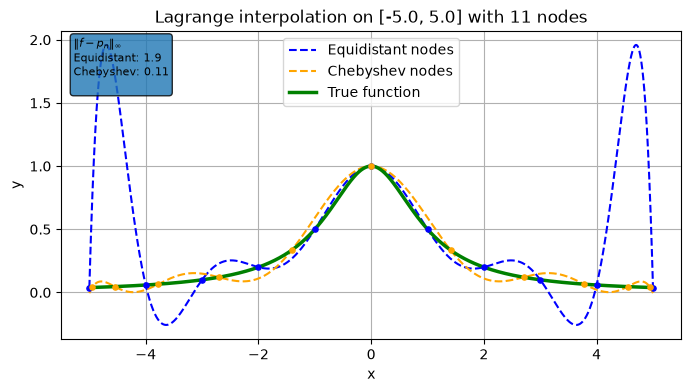

In [3]:
interval_a_wide = (-5.0, 5.0)

fig, ax = plot_chebyshev_equidistant_lagrange (
    fun = runge,
    interval = interval_a_wide,
    n = 10,
    points = 5001,
    savefig = SAVE_FIGURES,
)

#### (i) 
The Chebyshev nodes should at least continue to give lower approximation error than the equidistant nodes, as we have proven that Chebyshev nodes give the lowest Lagrangian approximation error. But we are not guaranteed that it converges as n increases, since Faber's guarantees that there exists at least some $f \in C(a, b)$ such that the interpolation polynomial diverges (this might be that function for all I know). 

I notice that the nodes on Chebyshev are much more compact around the area of which the equidistant nodes diverge, stopping the same divergence from happening in the Chebyshev. When increasing n I think that the Chebyshev will continue to increase nodes at the ends, decreasing error. However, it seems as if the equidistant error propagates and grows larger between each node. Then increasing nodes should might also increase the error.

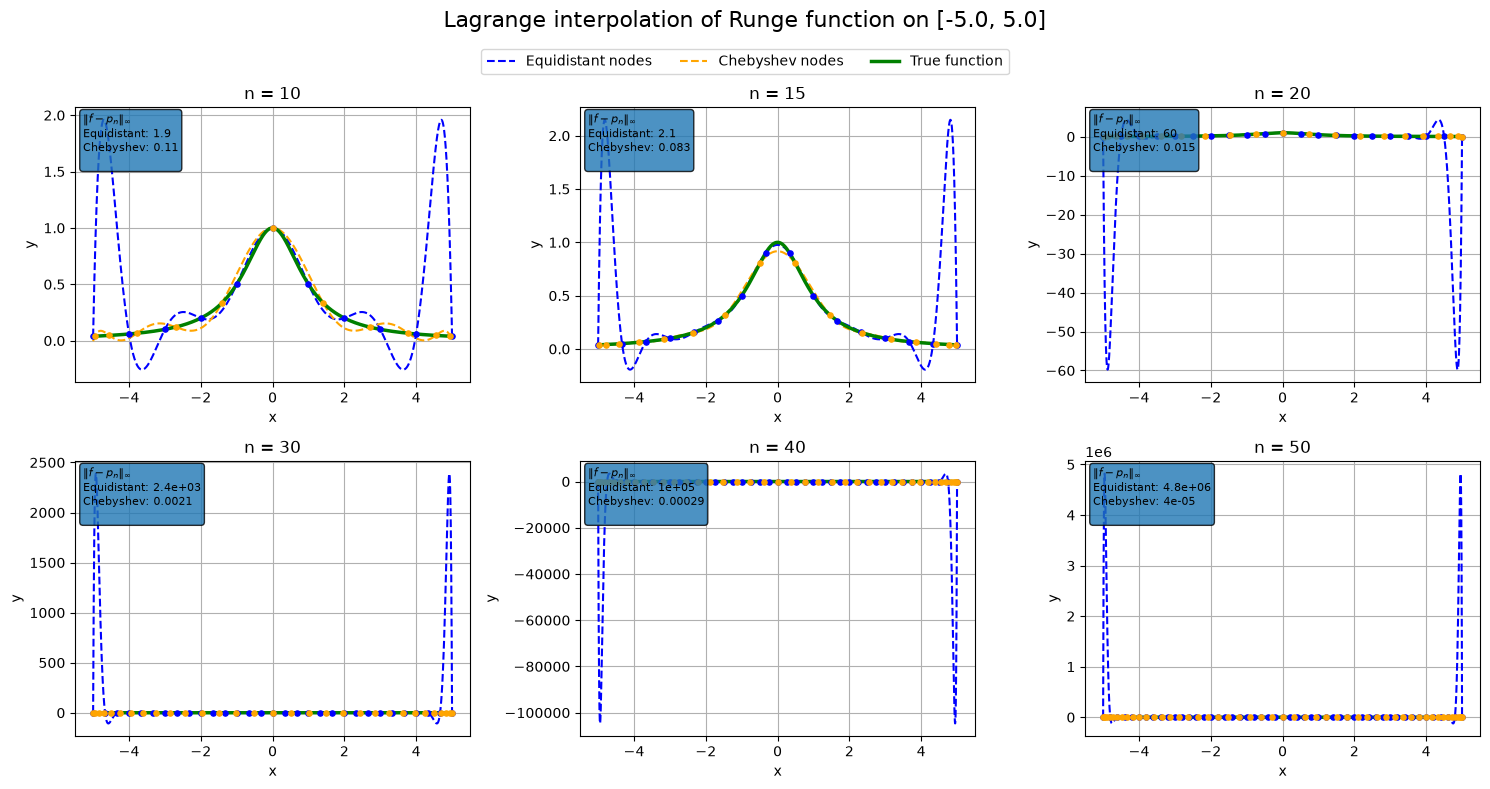

In [4]:
n_arr_a = np.array([10, 15, 20, 30, 40, 50], dtype = np.int64)

fig, axs = plot_multiple_n_lagrange(
    fun = runge,
    interval = interval_a_wide,
    n_arr = n_arr_a,
    points = 5001,
    savefig = SAVE_FIGURES,
)
plt.show()

#### (ii)

I notice that that the Chebishev error continues decreasing, while the equidistasnt error blows up. This is like my initial guess, yet somewhat surprising as one intuively might would've expected that the error should decrease as we increase the nodes, similarly to how training error of regression decreases when allowing for more degrees of freedom.

The proof of convergence on such interval is somewhat complex and seems to require using the Bernstein ellipse, which is both beyond the curriculum and my current knowledge, so I won't do this, but will add my attempted proof of convergence for the Chebishev nodes in Lagrange interpolation on the Runge polynomial in the appendix. 

My strongest argument for this lies in the fact that Chebyshev nodes cluster near the endpoints, where the equidistant interpolation develops its largest oscillations and consequently the error should decrease over the entire interval as well. By clustering near the endpoints the factor
\begin{align*}
|\prod_{j = 0}^n (x - x_j)| 
\end{align*}
should remain low near the endpoints (x \approx a, x \approx b) which we observed was the peaks of the error. This should therefore likely reduce
\begin{align*}
\max_{x \in [a, b]} |\prod_{j = 0}^n (x - x_j)| 
\end{align*}
as well. Thus interpolation errors are amplified much less than for equidistant nodes.

The reason for the higher node density at the end points for the Chebyshev nodes follows from the definition. $\theta = \frac{(2j + 1) \pi}{2(n + 1)}$ is eveny spaced, but then we apply the $\cos \theta$ function and look at the zeros. For a small angled step, $| \Delta x \| \approx | \frac{\Delta x}{\Delta \theta}| \Delta \theta = |\sin{\theta} |\Delta \theta$. $\sin{\theta}$ is low near $\theta \approx 0$ and $\theta \approx \pi$ which corresponds to $x_i = \cos (\theta_i) \approx \pm 1$, while near the centre $\sin \theta \approx 1$. Thus nodes near the centre are spaced far apart, while near the endpoints they are spaced closer together.

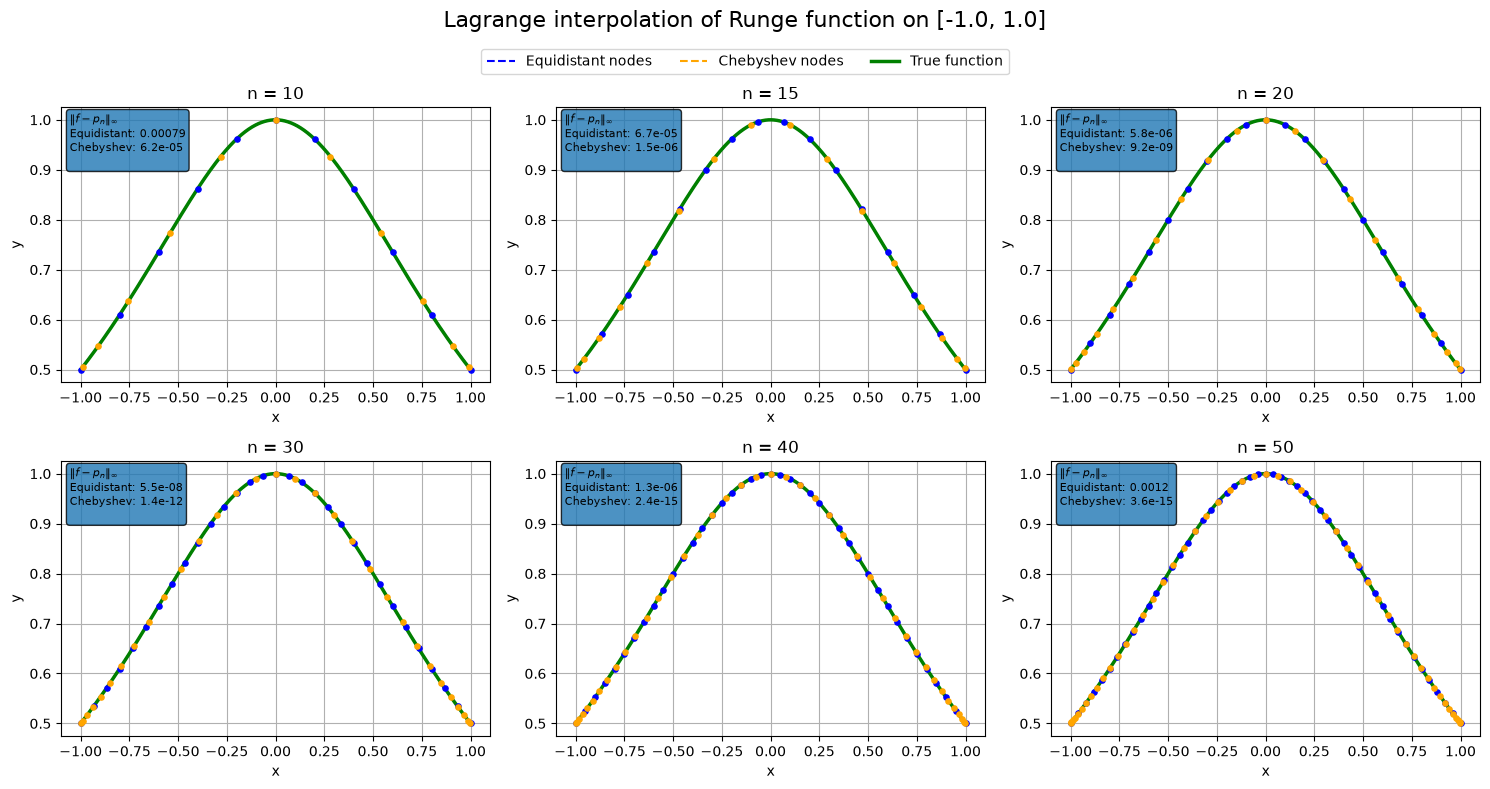

In [5]:
interval_a_small = (-1.0, 1.0)

fig, axs = plot_multiple_n_lagrange(
    fun = runge,
    interval = interval_a_small,
    n_arr = n_arr_a,
    points = 5001,
    savefig = SAVE_FIGURES,
)
plt.show()

The equidistant nodes seems to no longer diverge as much near the end points. Interestingly the error starts decreasing, before increasing again past ~n = 30, indiciating the same divering property but perhaps at a lesser degree or just a numerical roundoff error. THis might be because a smaller interval decreases the possible value of $|\prod_{j = 0}^n (x - x_j)|$. The Chebyshev still seems to converge as expected.

#### (iii)
We notice that the error has dropped drastically. The Chebyshev error is still the lowest as expected, but the equidistant nodes no longer diverge for increasing n as they did previously. At n = 50 I notice that the equidistant error starts to increase again, which is interesting. So did the CHebyshev nodes. 

# b) Error convergence and interpolation bounds

### (i)

Since $x_i, x_j \in [a, b]$,  $a,b \in R$ we have that $\| x - x_j \| \leq b - a$. We know that the interpolation error is
\begin{align*}
f - p_n \leq \frac{f^(n+1) (\xi_x)}{(n + 1)!} \prod_{j = 0}^n (x - x_j)
\end{align*}
so that
\begin{align*}
||f - p_n|| \leq \frac{\| f^{(n+1)} \|}{(n + 1)!} \prod_{j = 0}^n \|(x - x_j)\|
\end{align*}

Consider $f(x) := \cos{(2 \pi x)}$, $x \in [0, 1]$. Then $b = 1$, $a = 0$ and $f^{(n)} = (2 \pi)^n \cos{(2 \pi x + \frac{n \pi}{2})}$  which gives
\begin{align*}
&||f - p_n|| \leq \frac{\| (2 \pi)^{n+1} \cos{2 \pi x}\|}{(n + 1)!} (1 - 0)^{n + 1} \leq \frac{(2 \pi)^{n + 1}}{(n + 1)!} \\
\implies \lim_{n \rightarrow \infty} &\|f - p_n\|_\infty = 0 = \lim_{n \rightarrow \infty} \|f - p_n \|_2
\end{align*}
since $n!$ is asympotitcally larger than $a^n$.

Now consider $g(x) := \exp{(3x)} \sin{(2x)}$, $x \in [0, \frac \pi 4]$. Then $b = \frac \pi 4$, $a = 0$. We examine the derivative:
\begin{align*}
g'(x) = 3\exp{(3x)} \sin{(2x)} + 2 \exp{(3x)} \cos{(2x)}
\end{align*}
Notice that each differentiation doubles each term, so $g^{(n+1)}$ will have $2^{n+1}$ terms. Each differentation produces terms of the form $C \exp{(3x)} \sin{(2x)}$ or $C \exp{(3x)} \cos{(2x)}$, and $C$ must be bounded by $2^{n+1} 3^{n+1}$. $x \in [0, \frac \pi 4]$, thus
\begin{align*}
\| g^{(n+1)}\| \leq 2^{n+1} 2^{n+1} 3^{n+1} \exp{(\frac{3 \pi}{4})} = 12^{n+1} \exp{(\frac{3 \pi }{4})}
\end{align*}
That gives
\begin{align*}
&||g - p_n|| \leq \frac{\| 12^{n + 1} \exp{(\frac{3 \pi}{4})} \|}{(n + 1)!} (\frac \pi 4 - 0)^{n + 1} =  \exp{(\frac{3 \pi}{4})} \frac{(3 \pi)^{n + 1}}{(n + 1)!} \\
\implies \lim_{n \rightarrow \infty} &\| g - p_n \|_\infty = 0 = \lim_{n \rightarrow \infty} \| g - p_n \|_2
\end{align*}

Thus $p_{f, n} \to f$ and $p_{g,n} \to g$ in both max and second norm. $\square$


One can also prove g convergences by deriving alternate limit for $\| g^(n + 1) \|$ which proves nice if one wishes to include a non numerical bound estimate for the g function:
\begin{align*}
g(x) &= \exp{(3x)} \sin{2x} = \Im (\exp{(3 + 2i)x}) \\
\implies g^{(n + 1)}(x) &= \Im ( (3 + 2i)^{n + 1} \exp{(3 + 2i)x}) \\
\implies |g^{(n + 1)}(x)| &\leq |3 + 2i|^{n + 1} |\exp{(3 + 2i)x}| = (13)^{\frac{(n + 1)}{2}}\exp{3x}
\end{align*}
$x \in [0, \frac \pi 4]$ so  
\begin{align*}
|g^{(n + 1)}(x)| \leq (13)^{\frac{n + 1}{2}}\exp{\frac {3 \pi}{4}}
\end{align*}
and 
\begin{align*}
\|g - p_n\| \leq \exp{(\frac{3 \pi}{4})} \frac{(\frac{\pi \sqrt{13}}{4})^{n+1}}{(n + 1)!}
\end{align*}

### (ii) + (iii)

Using the derived interpolation error for f we get two possible theoretical interpolation bounds for f
\begin{align*}
||f - p_n||_\infty &\leq \frac{(2 \pi)^{n+1}}{(n + 1)!} \\
||f - p_n||_\infty &\leq \frac{(2 \pi)^{n+1}}{(n + 1)!} \prod_{j = 0}^n (x - x_j)
\end{align*}
The second (ASD) one requires more computation but is also tighter. I plot both for comparison.

We can simplify the bound even further when using Chebishev nodes. THe Chebyshev nodes uses the roots of the Chebyshev polynomial $T_{n+1}(x)$, where $T_n(x) = \cos{(n \arccos {x})}$. We know that $2^{-n} T_{n + 1}(x)$ is a monic polynomial. That means we can write 
\begin{align*}
    T_{n+1}(t) &= 2^n \prod_{j = 0}^n (t - t_j) \\
    \implies 2^{-n} T_{n + 1}(t) &= \prod_{j = 0}^n (t - t_j)
\end{align*}
Where $t_j$ is the zeros of the Chebyshev polynomial, and thus the nodes. It follows from the definition of $T_n(x)$ that $\|T_{n+1} (x) \| \leq 1$ on $x \in [-1, 1]$. Map $t, t_j \in [-1, 1]$ to $x, x_j \in [a, b]$ by  $x_j = \frac{a + b}{2} + \frac{b - a}{2} t_j$ and likewise for x $ \implies x - x_j = \frac{b - a}{2} (t - t_j)$. $\|T_n(t_j) \| \leq 1 \forall t_j \in [-1, 1]$ ($\iff x_j \in [a, b]$) which then gives
\begin{align*}
    \| \prod_{j = 0}^n (x - x_j) \| =  (\frac{b - a}{2})^{n+1} \| \prod_{j = 0}^n (t - t_j) \|  = (\frac{b - a}{2})^{n+1} \|2^{-n} T_{n+1} (t)\| \leq (b - a)^{n + 1} 2^{-(2n + 1)}
\end{align*}

In our case $b - a = 1$, so 
\begin{align*}
    \| \prod_{j = 0}^n (x - x_k) \| = 2^{-(2n + 1)}
\end{align*}
and we get the Chebyshev bound for f:
\begin{align*}
||f - p_n||_\infty \leq \frac{\| f^{(n+1)} \|}{(n + 1)!} \prod_{j = 0}^n (x - x_j) \leq \frac{(2 \pi)^{n + 1}}{(n + 1)!} 2^{-(2n + 1)}
\end{align*}

Similarly for g, with $L = \frac \pi 4$ we get numerical bound, theoretical bound (from the alternate imaginary derivation) and Chebyshev bound, respectively:
\begin{align*}
\|g - p_n\|_\infty &\leq \frac{(13)^{\frac{n + 1}{2}}\exp{\frac {3 \pi}{4}}}{(n +1)!} \| \prod_{j = 0}^n (x - x_k) \|_\infty \\
\|g - p_n\|_\infty &\leq \exp{(\frac{3 \pi}{4})} \frac{(\frac{\pi \sqrt{13}}{4})^{n+1}}{(n + 1)!} \\
\|g - p_n\|_\infty &\leq \frac{(13)^{\frac{n + 1}{2}}\exp{\frac {3 \pi}{4}}}{(n +1)!} \frac{(\frac{\pi}{4})^{n + 1}}{2^{2n + 1}}
\end{align*}

In [6]:
from tma4215_project1.interpolation.nodes import(
    generate_equidistant_nodes,
    generate_chebyshev_nodes,
)
from tma4215_project1.analysis.computations.lagrange_computations import(
    lagrange_error_norms_multiple_n,
    estimate_lagrange_max_sum,
)
from tma4215_project1.analysis.plots.lagrange_plots import(
    compare_l2_max_norm,
)

Function $f(x) = \cos{2 \pi x}$:

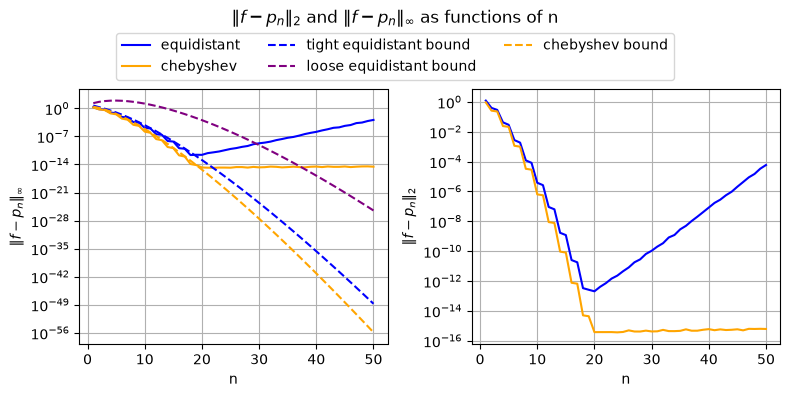

In [7]:
n_arr_b = np.arange(1, 51, dtype = np.int64)

fig, axs = compare_l2_max_norm(
    fun = f,
    interval = (0.0, 1.0),
    n_arr = n_arr_b,
    bound = True,
    savefig = SAVE_FIGURES,
    fun_type = 'f',
)
plt.show()

Function $g(x) = \exp{(3x)}\sin{2x}$:

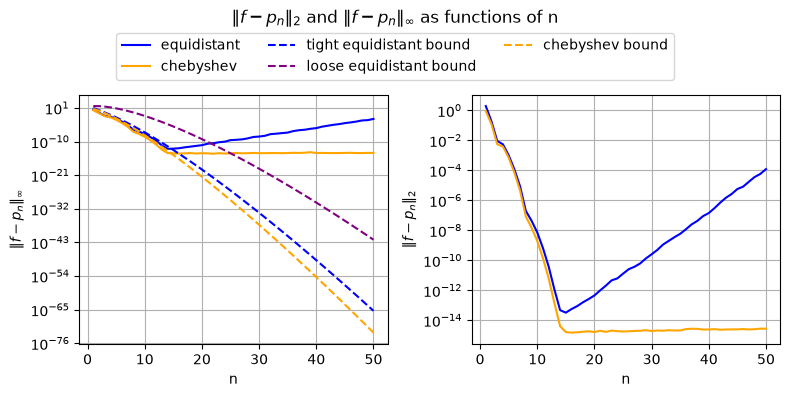

In [8]:
fig, axs = compare_l2_max_norm(
    fun = g,
    interval = (0.0, np.pi / 4),
    n_arr = n_arr_b,
    bound = True,
    savefig = SAVE_FIGURES,
    fun_type = 'g',
)
plt.show()

Comparison of theoretical bounds to computed error for $f(x)$:

In [9]:
(
    equidistant_max_err,
    equidistant_l2_err,
    chebyshev_max_err,
    chebyshev_l2_err,
    equidistant_tight_bound,
    equidistant_loose_bound,
    chebyshev_bound,
) = lagrange_error_norms_multiple_n(
    fun = f,
    interval = (0.0, 1.0),
    n_arr = n_arr_b,
    N = 5000,
    bound = True,
    fun_type = 'f'
)

equidistant_tight_gap_relative = equidistant_tight_bound /equidistant_max_err
equidistant_loose_gap_relative = equidistant_loose_bound /equidistant_max_err
chebyshev_gap_relative = chebyshev_bound/chebyshev_max_err

selected = n_arr_b % 5 == 0

for n, equidistant_tight_value, equidistant_loose_value, chebyshev_value in zip(
    n_arr_b[selected],
    equidistant_tight_gap_relative[selected],
    equidistant_loose_gap_relative[selected],
    chebyshev_gap_relative[selected],
):
    print(
        f'n = {n:2d}: '
        f'Tight equidistant = {equidistant_tight_value:.6e}, '
        f'Loose equidistant = {equidistant_loose_value:.6e}, '
        f'Chebyshev = {chebyshev_value:.6e}'
    )

n =  5: Tight equidistant = 1.476310e+00, Loose equidistant = 1.364861e+03, Chebyshev = 1.305666e+00
n = 10: Tight equidistant = 4.787696e+00, Loose equidistant = 1.149194e+06, Chebyshev = 4.688663e+00
n = 15: Tight equidistant = 1.136428e+00, Loose equidistant = 5.535251e+07, Chebyshev = 1.138125e+00
n = 20: Tight equidistant = 5.061000e-02, Loose equidistant = 4.542253e+08, Chebyshev = 2.895165e-01
n = 25: Tight equidistant = 1.208298e-08, Loose equidistant = 1.898041e+04, Chebyshev = 4.008570e-07
n = 30: Tight equidistant = 1.330186e-15, Loose equidistant = 3.542438e-01, Chebyshev = 1.548336e-13
n = 35: Tight equidistant = 7.321777e-23, Loose equidistant = 3.234425e-06, Chebyshev = 2.782084e-20
n = 40: Tight equidistant = 1.614069e-30, Loose equidistant = 1.164444e-11, Chebyshev = 2.191503e-27
n = 45: Tight equidistant = 1.897166e-38, Loose equidistant = 2.208519e-17, Chebyshev = 1.228588e-34
n = 50: Tight equidistant = 1.381362e-46, Loose equidistant = 2.571573e-23, Chebyshev = 4.6

The loose bound, obtained using $|x - x_j| \leq 1$ is way more pessimistic than the tight bound, using the numerical calculation of $\max_{x \in [0, 1]}| \prod_{j = 0}^n (x - x_j) |$. For n = 5, 10, 15 it overestimates the error norm by approximately $1.36 \cdot 10^3$, $1,15 \cdot 10^6$ and $5.5 \cdot 10^7$ respectively. We notice that the difference increases, meaning that the max error norm decreases faster with increasing n than the bound would suggest. When we use the tight bound instead these numbers drop to $1.48$, $4.79$ and $1.14$ instead, while the chebyshev bound stays the tighest (which makes sense as it is even tighter than the tight bound, since we could simplify the numerical limit to $2^{-(2n + 1)}$). 

Since the tight numerical bound is relatively close to the observed error for $n = 5, 10, 15$ while the loose bound is several orders of magnitude larger, the gap is mainly caused by the estimate $|x - x_j| \leq 1$ for the product term, rather than the derivative bound. For Chebyshev nodes, this term is exactly $2^{-(2n + 1)}$ and is thus not a source of looseness for the Chebyshev bound.

However, past n = 20 the Chebishev error stops decreasing , while the equidistant error starts increasing, which appears to contradict with the theoretical bounds. I think this must be due to numeric floating point errors. For the used data datatype, np.float64, the machine $\epsilon$ (smallest $\epsilon$ of which 1 and 1 + $\epsilon$ can be distinguished) is:


In [10]:
print(f'Machine epsilon: {np.finfo(np.float64).eps}')

Machine epsilon: 2.220446049250313e-16


This is close to where the norms start exhibiting their weird behaviour around $10^{-14} – 10^{-12}$. The reason the behaciour starts earlier, is in my theory due do numeric operations around this interval, which causes the combination of the operations to approach machine epsilon precision limit, despite the error being a bit higher.

Let the computed interpolant be $\tilde{p_n}$, then $\|f - \tilde{p_n}\|_\infty = \| (f - p_n)  + (p_n - \tilde{p_n})\|_\infty \leq \| f - p_n \|_\infty + \|p_n - \tilde{p_n} \|_\infty$, where $p_n$ is the true and analytical interpolant. The first term represents the exact interpolation error while the second term is the roundoff error. When approaching low numbers around $10^{-14}$–$10^{-15}$ it is likely that our numerical operations approach the machine epsilon, giving rounding errors. That is why neither are able to continue decreasing. 

For the sake of simplicity assume that the basis polynomials remains accurate (this doesn't affect the arugment), such that only the function has roundoff error which gives $ \tilde{p_n} - p_n = \sum_{j = 0}^n \delta_j L_j(x)$. $L_j(x) = \prod_{k \neq j} \frac{x - x_k}{x_j - x_k} \implies \| \tilde{p_n} - p_n \| \leq \max_j | \delta_j | \max_{x \in [0, 1]} \sum_{j = 0}^n |L_j(x)|$.

I analyze the size of $L_j(x)$ for equidistant and Chebyshev across different configurations of n.

In [11]:
interval_b_constant = (0.0, 1.0)
grid_b_constant = np.linspace(*interval_b_constant, 10000)

for n in [1, 10, 15, 20]:
    equidistant_nodes = generate_equidistant_nodes(interval = (0.0, 1.0), n = n)
    chebyshev_nodes = generate_chebyshev_nodes(interval = (0.0, 1.0), n = n)
    
    equidistant_constant = estimate_lagrange_max_sum(nodes = equidistant_nodes, grid = grid_b_constant)
    chebyshev_constant = estimate_lagrange_max_sum(nodes = chebyshev_nodes, grid = grid_b_constant)
    
    print(
        f'n = {n:2d}: '
        f'equidistant = {equidistant_constant:.3f}, '
        f'Chebyshev = {chebyshev_constant:.3f}'
    )

n =  1: equidistant = 1.000, Chebyshev = 1.414
n = 10: equidistant = 29.900, Chebyshev = 2.489
n = 15: equidistant = 512.350, Chebyshev = 2.728
n = 20: equidistant = 10986.654, Chebyshev = 2.901


We notice that the constant increases for the equidistant nodes while staying somewhat constant for the Chebyshev, providing a numerical explanation for the behaviour of the errors.

# c) 

### (i)

In [12]:
from tma4215_project1.analysis.plots.piecewise_plots import (
    plot_piecewise_interpolation,
    compare_piecewise_global_max_error,
    piecewise_lagrange_k,
)
from tma4215_project1.analysis.computations.runtime_computations import (
    interpolation_runtime_comparison,
)

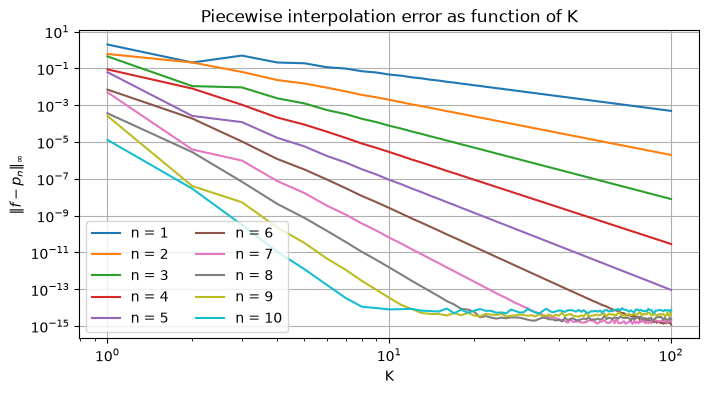

In [13]:
interval_c = (0, 1.0)

grid_c = np.linspace(*interval_c, 5001)
k_arr_c = np.arange(1, 101, dtype=np.int64)

fig, ax = plt.subplots(figsize = (8, 4))

for n_local in range(1, 11):
    max_err, _ = piecewise_lagrange_k(
        fun = f,
        x = grid_c,
        k_arr = k_arr_c,
        n = n_local,
        interval = interval_c,
    )
    
    ax.plot(k_arr_c, max_err, label = f'n = {n_local}', markersize = 3)
    
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('K')
ax.set_ylabel(r'$\|f-p_n\|_\infty$')
ax.set_title('Piecewise interpolation error as function of K')
ax.grid()
ax.legend(ncol = 2) 

plt.show()

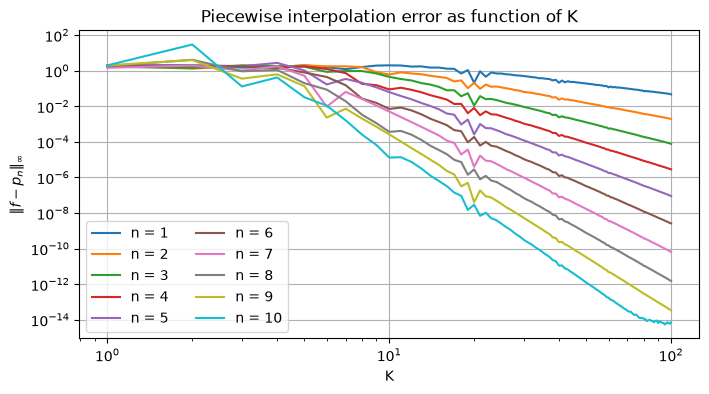

In [14]:
fig, ax = plt.subplots(figsize = (8, 4))

for n_local in range(1, 11):
    max_err, _ = piecewise_lagrange_k(
        fun = f,
        x = grid_c,
        k_arr = k_arr_c,
        n = n_local,
        interval = (-5.0, 5.0),
    )
    
    ax.plot(k_arr_c, max_err, label = f'n = {n_local}', markersize = 3)
    
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('K')
ax.set_ylabel(r'$\|f-p_n\|_\infty$')
ax.set_title('Piecewise interpolation error as function of K')
ax.grid()
ax.legend(ncol = 2) 

plt.show()

In code the interval is divided into K subintervals, where each subinterval are left-closed and right-open, except the final interval which is both left-closed and right-closed to cover entire interval. The node construciton does however include both left and right boundary of each interval, so boundary nodes are linked, meaning: $p_{i-1}(v_i) = f(v_i) = p_i(v_i)$. Thus the piecewise interpolation function preserves continuity. This is also numerically supported by the interpolation plot in b) (ii) where it seems clear the interpolation polynomial is continuous. 

The way the intervals are assigned directly affects the number of discretization nodes count in the code. Each subinterval contains n + 1 nodes, but we have to subtract the nodes shared by two neighboring polynomials in each internal boundary (K-1) as well, giving $K(n+1) - (K - 1) = nK + 1$ nodes in total. This result is implemented consistently through the code, and is used for later analysis.

Define width of interval $h := \frac{b - a}{K} = \frac {1}{K}$. Then for f(x), on each subinterval (as we showed previously)
\begin{align*}
\|f(x) - p_i(x) \|_\infty = \max_{x \in I_i} |f(x) - p_i(x)| \leq \frac{(2 \pi)^{n + 1}}{(n + 1)!} (\frac{1}{K})^{n+1}
\end{align*}
The total max error over the entire interval will then be the maximmum possible error on either of these subintervals, thus
\begin{align*}
\|f(x) - p_{n, K}(x) \|_\infty = \max_{I_i \subset I} \| f(x) - p_i(x) \|_\infty \leq \frac{(2 \pi)^{n + 1}}{(n + 1)!} (\frac{1}{K})^{n+1}
\end{align*}

Which should approach zero as $K \rightarrow \infty$. The plot provides numerical evidence that this is the case. Since upper bound of error was propotional to ${K}^{-(n+1)}$ we also expect that higher n should give steeper decline as function of $K$ which also seems to be the case.

Since $\|f(x) - p_i(x) \|_\infty = O(K^{-(n + 1)}) \implies \|f(x) - p_i(x) \| \approx C K^{-(n + 1)}$, then
\begin{align*}
\log{\|f(x) - p_i(x) \|_\infty} \approx \log C - (n + 1) \log K
\end{align*}
Since we also plot $\log K$ along the x-axis, we except the error to follow a linear trend, which seems to be the case.

Interestingly, when expanding the interval to $(-5, 5)$ we also notice sudden dips in error. I choose not to go too much into depth to this, as this interval was not a part of the task, but my intuition is that this has to do with the periodicity of the f function on the nodes, since the dips are reccuring.

### (ii)

Global interpolation of f:

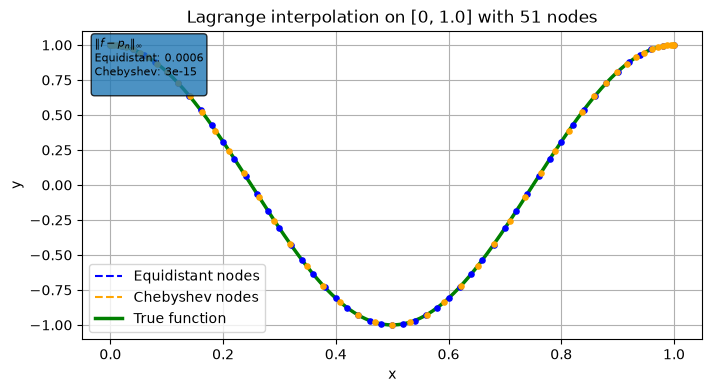

In [15]:
fig, ax = plot_chebyshev_equidistant_lagrange(
    fun = f,
    n = 50,
    interval = interval_c,
    savefig = SAVE_FIGURES,
)

Piecewise interpolation on f:

Here I chose to omit the nodes. Since there are $K \cdot n + 1 = 51$ nodes which is very dense.

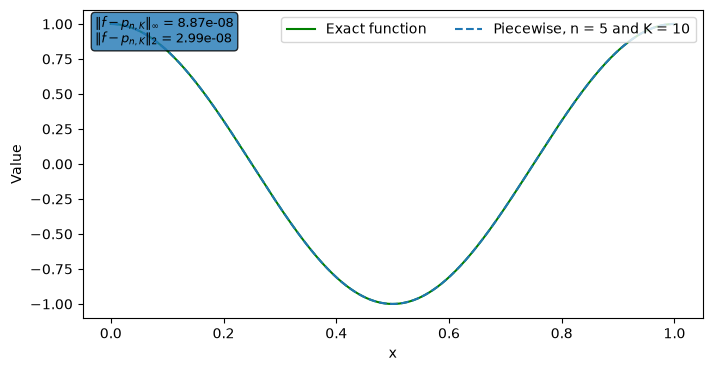

In [16]:
fig, ax = plot_piecewise_interpolation(
    fun = f,
    x = grid_c,
    k = 10,
    n = 5,
    interval = interval_c,
    savefig = SAVE_FIGURES,
)

Error in both max and second norm is much lower than achieved for the Chevishev and equidistional nodes in global Lagrante interpolation. Additionally we see the second norm is smaller than the infinite norm which is a positive indicator of the calculations being correct.

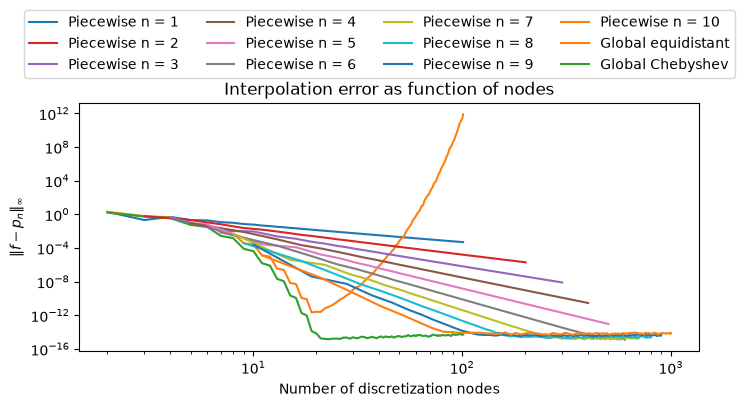

In [17]:
n_arr_comparison = np.arange(1, 11, dtype = np.int64)
max_K = 100 #max 100 + 1 = 101 distinct nodes

fig, ax = plt.subplots(figsize = (8, 4))

for i, n in enumerate(n_arr_comparison):
    k_arr = np.arange(1, max_K + 1, dtype = np.int64)
    
    fig, ax = compare_piecewise_global_max_error(
        fun = f,
        x = grid_c,
        k_arr = k_arr,
        n = int(n),
        interval = interval_c,
        ax = ax,
        plot_global = (i == 0),
        savefig = SAVE_FIGURES,
    )

Here, we also notice the linearity as discussed, as number of distinct nodes is $N = nK + 1$. The equidistant decreases to $10^{-12}$ before diverging while Chebyshev flattens out as a result of the roundoff errors,  like I discussed earlier,. The Chebyshev seems to converge much faster than any of the methods, and the equidistant also converges faster than the piecewise algorithm. We saw previously that error was loglog linear as a funciton of K while n detemrines the slope. Thus increasing n should give a steeper negative slope, which also seems to be the case.

The error functions stop at different nodes because a piecewise interpolant of n local degrees with given $K_max$ subintervals at max can have $n K_{max} + 1$ nodes.

### (iii)

In [18]:
k_arr_runtime = np.array([1, 2, 4, 8, 16, 32, 64], dtype = np.int64)

runtime_result = interpolation_runtime_comparison(
    fun = f,
    x = grid_c,
    interval = interval_c,
    n = 3,
    k_arr = k_arr_runtime,
    repeats = 100,
)

# AI formating
print(
    f"{'Nodes':>8}"
    f"{'Global min':>18}"
    f"{'Piecewise min':>20}"
    f"{'Global median':>18}"
    f"{'Piecewise median':>20}"
    f"{'Global std':>15}"
    f"{'Piecewise std':>17}"
)

for nodes, global_min_time, piecewise_min_time, global_time, piecewise_time, global_std, piecewise_std in zip(
    runtime_result["num_nodes"],
    runtime_result['global_min_time'],
    runtime_result['piecewise_min_time'],
    runtime_result["global_median_time"],
    runtime_result["piecewise_median_time"],
    runtime_result["global_std_time"],
    runtime_result["piecewise_std_time"],
):
    print(
        f"{nodes:8d}"
        f"{global_min_time:18.6e}"
        f"{piecewise_min_time:20.6e}"
        f"{global_time:18.6e}"
        f"{piecewise_time:20.6e}"
        f"{global_std:15.2e}"
        f"{piecewise_std:17.2e}"
    )
# AI formating

   Nodes        Global min       Piecewise min     Global median    Piecewise median     Global std    Piecewise std
       4      6.650004e-05        8.129200e-05      8.816703e-05        1.067500e-04       4.62e-05         2.33e-05
       7      1.905420e-04        1.062080e-04      2.019170e-04        1.123125e-04       3.84e-05         1.49e-05
      13      6.415000e-04        1.646660e-04      6.602710e-04        1.699795e-04       1.68e-04         8.21e-06
      25      2.358708e-03        2.872500e-04      2.434520e-03        3.007505e-04       3.95e-04         2.15e-05
      49      9.145042e-03        5.150420e-04      1.066935e-02        5.348545e-04       1.96e-03         1.14e-04
      97      3.567683e-02        9.940420e-04      4.194754e-02        1.034625e-03       5.26e-03         5.44e-05
     193      1.423544e-01        1.854291e-03      1.443394e-01        1.927562e-03       2.79e-02         3.93e-05


On q nodes, the Lagrange interpolation method uses q nodes, each containing q - 1 factor, thus the runtime is $O(q^2)$. 

The global interpolation methods uses all N distinct nodes, so T(global) = $O(N^2) = O((nK+1)^2) = O(K^2n^2)$. The piecewise interpolation uses K local polynomials, each with n + 1 nodes, which gives a runtime of $O(N(n + 1)) = O(K(n + 1)^2) = O(Kn^2)$. There we should expect the piecewise interpolation method to have asymptotically lower runtime than the global interpolation.

I use both minimum and median over multiple iterations as my as reference for the runtime and measure for n = 3 (both methods are asymptotically equal for fixed K, so fixed n does not loose generaly generality). The minimum seems to be the best measuremenet, as noise for the computer only can make the measured runtime worse, not better. Comparing the two interpolation methods, I notice that the global interpolation takes shorter time in the beginning, before the piecewise interpolation method becomes faster for increasing number of distinct nodes, numerically confirming the asymptotical difference. 

For moderate number of nodes, global interpolation with Chebyshev nodes gives the fastest error reduction. Global equidistant inteprolation can initially converge rapidly but becmoes unstable at high degrees. Piecewise interpolation converges slower for fixed local degree, but remains stable, is local, and has lower asymptotic computational cost. I would therefore reccomend Chebyshev interpolation for node sizes, and peicewise interpolation for larger problems or when robustness is important.

# d) Radial basis function interpolation

### (i)

In [19]:
from tma4215_project1.analysis.computations.rbf_computations import (
    rbf_error_epsilon,
)
from tma4215_project1.analysis.plots.rbf_plots import (
    plot_cond_M,
    plot_rbf_error_epsilon,
    plot_rbf_error_condition,
    plot_rbf_interpolation,
)
from tma4215_project1.interpolation.methods import rbf
from tma4215_project1.interpolation.nodes import (
    generate_equidistant_nodes,
)
from tma4215_project1.analysis.computations.rbf_computations import cond_M

The radial basis function is implemented so that it can both calculate optimized nodes and $\epsilon$ using gradient descent, by setting include_optimized = True. This is why some non related variables: max_iter and the other variables below, is included as placeholders.

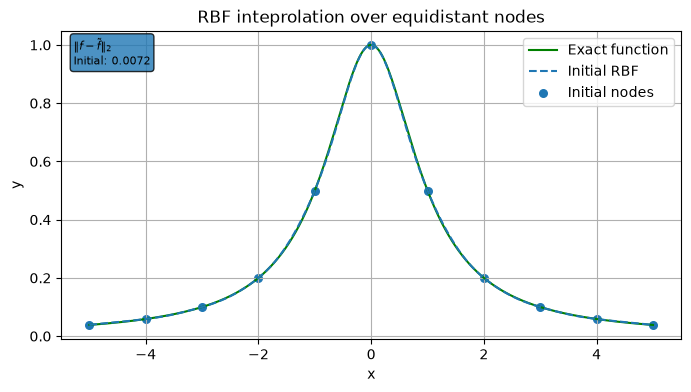

In [20]:
interval_d_runge = (-5.0, 5.0)
interval_d_f = (0, 1.0)

n_d = 10
grid_d_runge = np.linspace(*interval_d_runge, 5001)
grid_d_f = np.linspace(*interval_d_f, 5001)


fig, ax = plot_rbf_interpolation(
    fun = runge,
    n = n_d,
    interval = interval_d_runge,
    init_epsilon = 1.30,
    N = 1000,
    max_iter = 100,
    max_backtracks = 100,
    tol = 1e-6,
    L = 100.0,
    rho = 0.5,
    rho_bar = 2.0,
    epsilon_min = 1e-4,
    include_optimized = False,
    savefig = SAVE_FIGURES,
)
plt.show()

Use trial and error and get that optimal $\epsilon \approx 1.30$ which gives lower error than the global Chebyshev and Equidistant error that we observed in a).

### (ii)

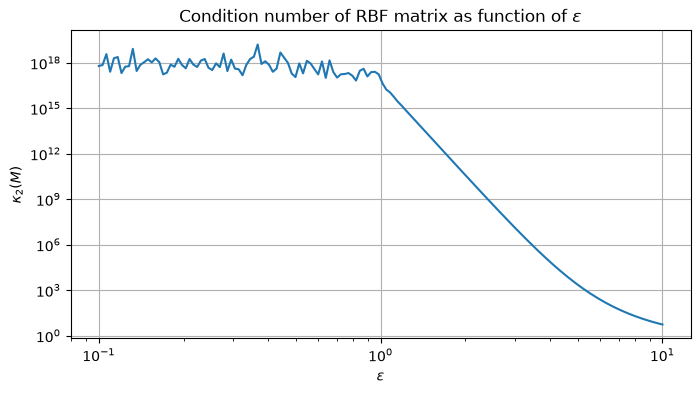

In [21]:
nodes_d_f = generate_equidistant_nodes(interval_d_f, n_d)
epsilon_arr_d_f = np.logspace(-1, 1, 150)


fig, ax = plot_cond_M(
    x_nodes = nodes_d_f,
    epsilon_arr = epsilon_arr_d_f,
    savefig = SAVE_FIGURES,
)

plt.show()

RBF linear system starts with $M c = y$. If we introduce $\tilde{y}  = y + \delta y$, $\tilde c = c + \delta$ (assume for simplicity that M has no error, without loosing the illustrative point of the derivation).
\begin{align*}
M(c + \delta c) &= y + \delta y \\
\implies Mc + M \delta c &= y + \delta y \\
\implies M \delta c &= \delta y \\
\implies \| \delta c \|_2 &\leq \|M^{-1}\|_2 \|\delta y\|_2
\end{align*}
We also know that:
\begin{align*}
\| y_2 \| &= \| Mc \|_2 \leq \| M \|_2 \| c \|_2 \\
\implies \| c \|_2 &\geq \frac{\| y \|_2}{\|M \|_2}
\end{align*}
Then
\begin{align*}
\frac{\| \delta c\|_2}{\| c \|_2} \leq \|M \|_2 \| M^{-1} \|_2 \frac{\| \delta y \|_2}{\| y \|_2} := \kappa_2(M) \frac{\| \delta y \|_2}{\| y \|_2} 
\end{align*}

For double precision, we saw the limit was around 10^{-16}. If e.g. $\kappa_2 (M) = 10^{6}$, then $\frac{\| \delta c\|_2}{\| c\|_2} \leq 10^6 \cdot 10^{-16} = 10^-10$. A relative error $10^-{10}$ means that approximately the first 10 significant decimal digits remain reliable, while the other 6 digits has been lost. Thus $\lg \kappa_2(M)$ represents number of digits lost due to roundoff error.

We see that the matrix becomes extremely ill conditioned for $\epsilon \lesssim 1.0$.

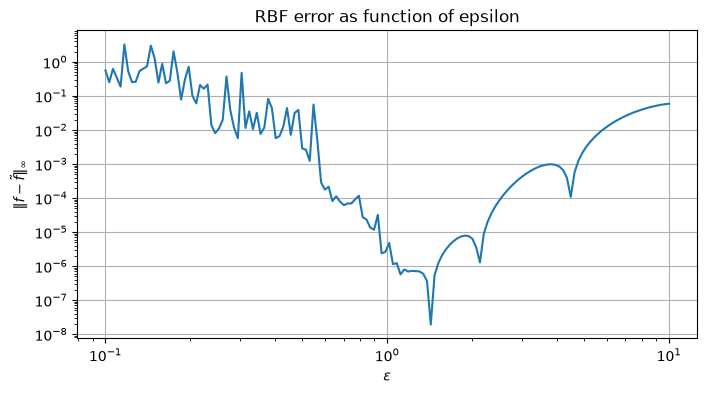

Selected epsilon: 1.4268
Maximum error: 1.92612e-08
L2 error: 5.60599e-09


In [22]:
fig, ax = plot_rbf_error_epsilon(
    fun = f,
    x_nodes = nodes_d_f,
    x = grid_d_f,
    interval = interval_d_f,
    epsilon_arr = epsilon_arr_d_f,
    savefig = SAVE_FIGURES,
)
plt.show()

f_max_errors, f_l2_errors = rbf_error_epsilon(
    fun = f,
    x_nodes = nodes_d_f,
    x = grid_d_f,
    interval = interval_d_f,
    epsilon_arr = epsilon_arr_d_f,
)
best_index = int(np.nanargmin(f_max_errors))
best_epsilon_d = float(epsilon_arr_d_f[best_index])

print(f'Selected epsilon: {best_epsilon_d:.6g}')
print(F'Maximum error: {f_max_errors[best_index]:.6g}')
print(f'L2 error: {f_l2_errors[best_index]:.6g}')

Numerically optimal $\epsilon$ at $1.4268$ with very low max and l2 error. We have however seen that by increasing n the error of global Chebyshev and equidistional interpolation, and piecewise interpolation was lower for f. 

In [23]:
_, condition_numbers = cond_M(x_nodes = nodes_d_f, epsilon_arr = epsilon_arr_d_f)

epsilon_targets = [0.1, 0.15, 0.5, 1.24, 7.0]

print(
    f"{'Epsilon':>12}"
    f"{'Condition number':>20}"
    f"{'Max error':>16}"
)

for target in epsilon_targets:
    index = int(np.argmin(np.abs(epsilon_arr_d_f - target)))

    print( 
        f"{epsilon_arr_d_f[index]:12.4g}"
        f"{condition_numbers[index]:20.4e}"
        f"{f_max_errors[index]:16.4e}"
        )

     Epsilon    Condition number       Max error
         0.1          6.1037e+17      5.6089e-01
      0.1495          1.7061e+18      1.2587e+00
      0.4989          1.1408e+17      2.8748e-03
       1.222          8.1238e+14      7.2308e-07
       6.901          6.1224e+01      2.4328e-02


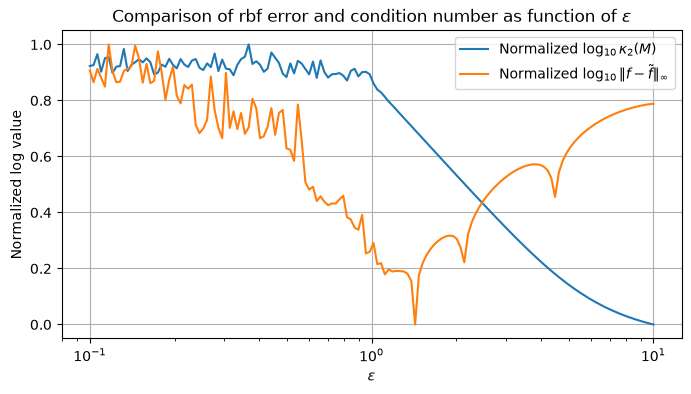

In [24]:
fig, ax = plot_rbf_error_condition(
    fun = f,
    x_nodes = nodes_d_f,
    x = grid_d_f,
    interval = interval_d_f,
    epsilon_arr = epsilon_arr_d_f,
    savefig = SAVE_FIGURES,
)
plt.show()

Small $\epsilon$ gives high condition number and therefore ill conditioned matrix, which in return gives high rbf error. The minimum error occurs near $\epsilon = 1.4268$ which is slightly past most ill conditioned region. Larger $\epsilon$ would give more narrow basis functions, which might not be beneficial for the interpolation, despite the condition number improving. Which illustrates the trade-off between accuracy and numerical stabiity.

### (iii)
Interpolation on f using best epsilon:

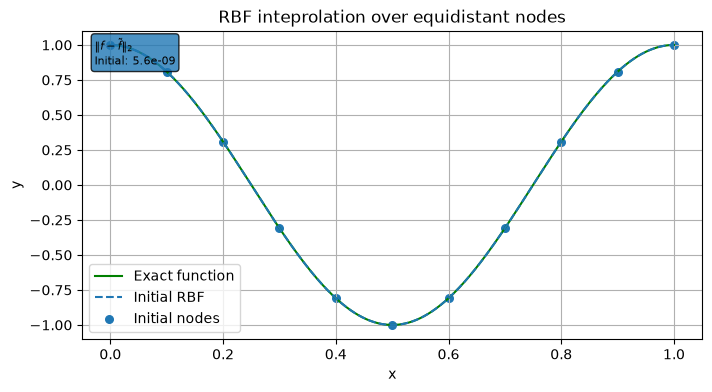

In [25]:
fig, ax = plot_rbf_interpolation(
    fun = f,
    n = n_d,
    interval = interval_d_f,
    init_epsilon = best_epsilon_d,
    N = 1000,
    max_iter = 100,
    max_backtracks = 100,
    tol = 1e-6,
    L = 100.0,
    rho = 0.5,
    rho_bar = 2.0,
    epsilon_min = 1e-4,
    include_optimized = False,
    savefig = SAVE_FIGURES,
)
plt.show()

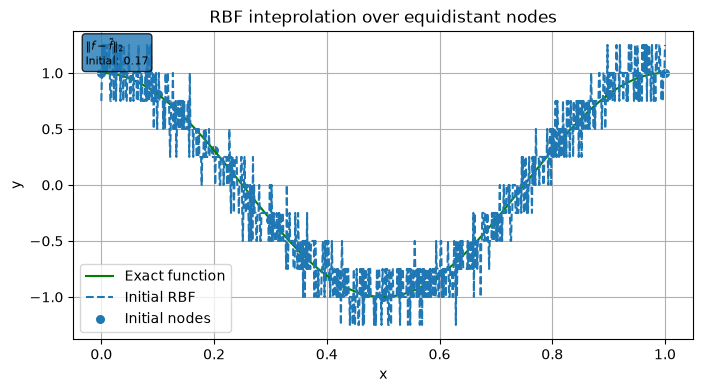

In [26]:
fig, ax = plot_rbf_interpolation(
    fun = f,
    n = 10,
    interval = interval_d_f,
    init_epsilon = 0.1,
    N = 1000,
    max_iter = 100,
    max_backtracks = 100,
    tol = 1e-6,
    L = 100.0,
    rho = 0.5,
    rho_bar = 2.0,
    epsilon_min = 1e-4,
    include_optimized = False,
    savefig = SAVE_FIGURES,
)
plt.show()

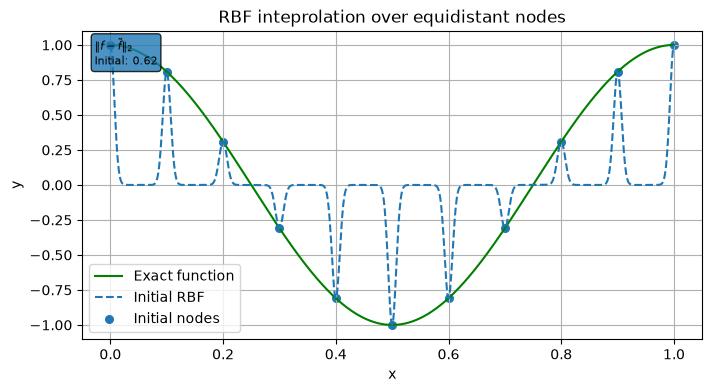

In [27]:
fig, ax = plot_rbf_interpolation(
    fun = f,
    n = 10,
    interval = interval_d_f,
    init_epsilon = 100,
    N = 1000,
    max_iter = 100,
    max_backtracks = 100,
    tol = 1e-6,
    L = 100.0,
    rho = 0.5,
    rho_bar = 2.0,
    epsilon_min = 1e-4,
    include_optimized = False,
    savefig = SAVE_FIGURES,
)
plt.show()

These illustrate the difference between optimal $\epsilon$ and $\epsilon$ in the divergence interval for RBF interpolation of f. A very small $\epsilon$ gives ill conditioned matrix and large roundoff errors. A very large $\epsilon$ gives narrow basis functions which might poorly approximate the function between the nodes. THe optimal value balances these two as we can see in the error estimates.

# e) Optimal RBF nodes and shapre parameter

In [28]:
import autograd.numpy as anp
from autograd import grad

from tma4215_project1.analysis.plots.rbf_plots import(
    plot_cost_history_L,
    plot_rbf_compare_n,
    plot_rbf_interpolation,
)
from tma4215_project1.interpolation.nodes import (
    generate_equidistant_nodes,
    make_cost,
)

### (i)

In [29]:
interval_e = (-5.0, 5.0)
n_e = 10
N_e = 1000
init_epsilon_e = 1.0
epsilon_min_e = 1e-4
max_iter_e = 100
max_backtracks_e = 100
tol_e = 1e-6
rho_e = 0.5
rho_bar_e = 2.0

In [30]:
initial_nodes_e = generate_equidistant_nodes(interval = interval_e, n = n_e)
z_initial_e = anp.concatenate((initial_nodes_e, anp.array([init_epsilon_e])))
cost_e = make_cost(runge, interval_e, N_e)
initial_gradient_e = np.asarray(grad(cost_e)(z_initial_e), dtype = np.float64)

print(f'Initial gradient: {initial_gradient_e}')
print(f'All entries finite: {np.all(np.isfinite(initial_gradient_e))}')

Initial gradient: [ 3.09418976e-05 -1.59488909e-04  1.64087950e-04 -1.37094358e-03
  1.01751924e-03 -8.67555217e-18 -1.01751924e-03  1.37094358e-03
 -1.64087950e-04  1.59488909e-04 -3.09418976e-05 -6.16590328e-03]
All entries finite: True


No NA in initial gradient, so we are ready to proceed to training. I avoid this issue by using $r^2 = (x- x_i)^2$ instad of $r = |x - x_i|$, avoiding potential singularities in the derivative.

As the training might give nodes outside interval or shape parameter $\epsilon < 0$ I also implemented a projection funciton that clips nodes and $\epsilon\$ to closes valid value if beyond valid scope. TThis keeps parameters within valid region during gradient descent.

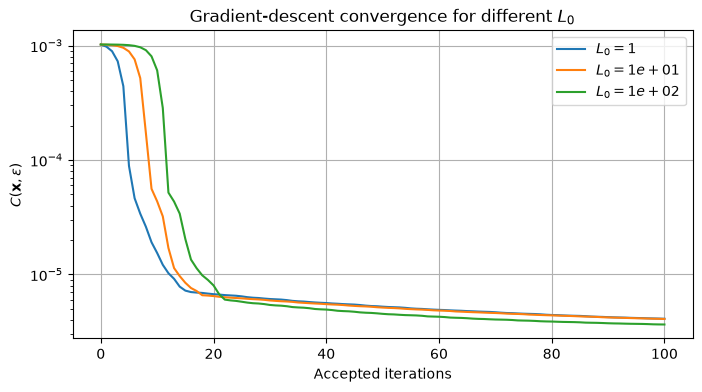

In [31]:
L_arr = np.array([1.0, 10.0, 100.0])

fig, ax = plot_cost_history_L(
    fun = runge,
    n = n_e,
    interval = interval_e,
    init_epsilon = init_epsilon_e,
    N = N_e,
    max_iter = max_iter_e,
    max_backtracks = max_backtracks_e,
    tol = tol_e,
    L_arr = L_arr,
    rho = rho_e,
    rho_bar = rho_bar_e,
    epsilon_min = epsilon_min_e,
    savefig = SAVE_FIGURES
)

For the tested $L_0$, the cost decreases steadily, possibly approaching local minima.

### (ii)

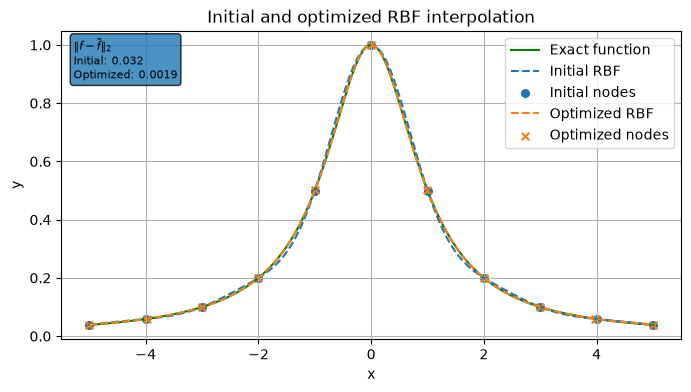

In [32]:
fig, ax = plot_rbf_interpolation(
    fun = runge,
    n = n_e,
    interval = interval_e,
    init_epsilon = init_epsilon_e,
    N = N_e,
    max_iter = max_iter_e,
    max_backtracks = max_backtracks_e,
    tol = tol_e,
    L = 100.0,
    rho = rho_e,
    rho_bar = rho_bar_e,
    epsilon_min = epsilon_min_e,
    savefig = SAVE_FIGURES, 
    include_optimized = True,
)

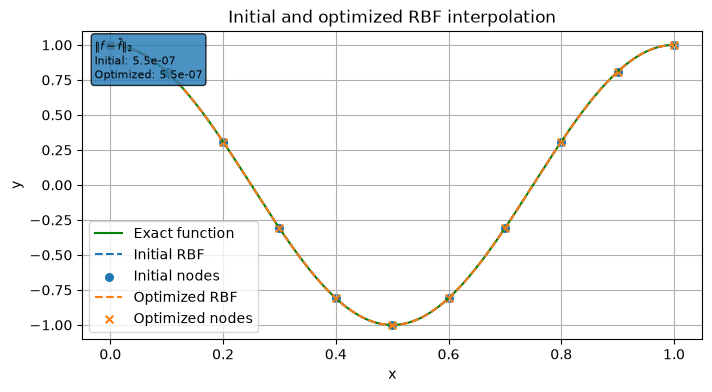

In [33]:
fig, ax = plot_rbf_interpolation(
    fun = f,
    n = n_e,
    interval = (0, 1.0),
    init_epsilon = init_epsilon_e,
    N = N_e,
    max_iter = max_iter_e,
    max_backtracks = max_backtracks_e,
    tol = tol_e,
    L = 100.0,
    rho = rho_e,
    rho_bar = rho_bar_e,
    epsilon_min = epsilon_min_e,
    savefig = SAVE_FIGURES, 
    include_optimized = True,
)

For the Runge function with n = 10, the optimization reduces the second norm error from approximately $3.20 \cdot 10^{-2}$ to $1.91 \cdot 10^-3$. Comprade with global Chebyshev and equidistional lagrange interpolation is substantially lower. 

The optimization is not guaranteed to find the global minimum, and therefore there might be another node and epsilon configuration with even lower error. The optimized RBF is not representative of the best possible RBF interpolation, but we have already found an RBF configuration with lower error than the global methods.

For f, the initial nodes and optimized nodes are all the same, as well as the $\epsilon$ vals indicating the equidistional nodes works very well for the RBF function.

### (iii)

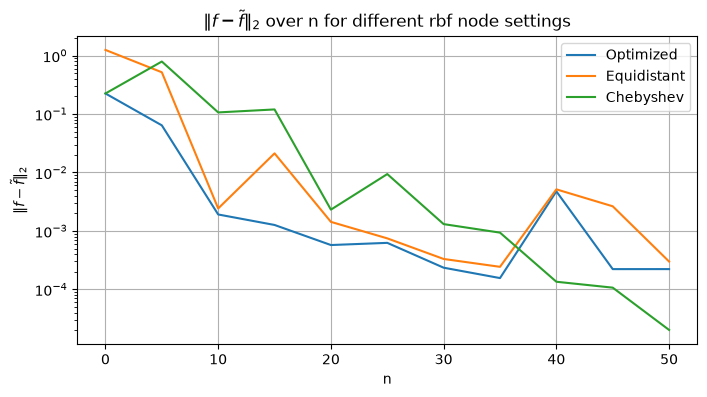

In [34]:
n_arr_e = np.arange(0, 51, 5, dtype = np.int64)

fig, ax = plot_rbf_compare_n(
    fun = runge,
    n_arr = n_arr_e,
    interval = interval_e,
    init_epsilon = init_epsilon_e,
    N = N_e,
    max_iter = max_iter_e,
    max_backtracks = max_backtracks_e,
    tol = tol_e,
    L = 100.0,
    rho = rho_e,
    rho_bar = rho_bar_e,
    epsilon_min = epsilon_min_e,
    savefig = SAVE_FIGURES
)

My interpretation of the task was to compare RBF interpolation over the Chebyshev and equidistant node configurations versus the optimized RBF. I have also been made aware that an alternative, and the most likely correct interpretation was to compare the old global Chebyshev and equidistant interpolation error vs the optimized, but I unfortunately did not have time to fix this. 

We can see for Runge that the equidistant configuration and optimized node configuration is already very close, explaining why the equidistand node configuration exhibits very similar behaviour to the optimized RBF interpolation for increasing n, boh decreasing and seemingly convering towards zero. One might expect the equidistant to diverge as we have seen for Runge previously, but this is not the case as the divergence applies to the Lagrange interpolation on the Runge function for equidistional nodes, not for RBF. The Chebyshev configuration also has decreasing error for increasing n, which might make sense, but again, we cannot predict the same behaviour for RBF as Lagrange.

One problem with this comparison is the choice of $\epsilon$. I chose to use the optimized epsilon as input for Chebyshev and Equidistant configuration, despite this being found only through the optimized RBF algorithm. This is somewhat more fair to focus only on node distribution differences, but the optimal $\epsilon$ is codependent on the node distribution, so it still remains a bit unfair. One option would be to implement a separate pure epsilon gradient descent algorithm for the equidistant and Chebyshev configuration, only minimizing the cost function with respect to $\epsilon$. I did not have time for this. One could also argue that this removes the point of the simple RBF configurations, and that it might be better to use a guessed $\epsilon$ than the optimized one. If not, all methods would inr eality use gradient descent to some degree. This depends entirely on the purpose of the comparison, and I concluded my main interest was of how the different node configurations (as independent of $\epsilon$) as possible affected the error development over n.

It is interesting to see that the Chebyshev configuration eventually reaches lower error than the optimized configuration, illustrating that configuration returned by gradient descent is not globally optimal. This may be because the method approached a local minimum or stopped before convergence.

# f) - Minimization of optimal polynomial

 Use that polynomial that approximates function best exists and is unique theorem. Weierstrass theorem

# Appendix
prof of interpolation bound

proof of chebyshev properties and optimality

proof of second norm less than max norm

best approximation theorem (f)

det vi har fått i e er ikke nødvendigvis optimalt

nodene må være distinkt